In [2]:
# ==========================================
# Principal Component Analysis (PCA) in Python
# Dataset: mtcars (loaded via pydataset)
# ==========================================

# 1️⃣ Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from pydataset import data  # allows access to built-in R datasets like mtcars




















initiated datasets repo at: C:\Users\sunsh\.pydataset/


In [3]:
# 2️⃣ Load and explore the dataset
mtcars = data('mtcars')
print("Preview of dataset:\n", mtcars.head(), "\n")
print("Shape of dataset:", mtcars.shape)

Preview of dataset:
                     mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  \
Mazda RX4          21.0    6  160.0  110  3.90  2.620  16.46   0   1     4   
Mazda RX4 Wag      21.0    6  160.0  110  3.90  2.875  17.02   0   1     4   
Datsun 710         22.8    4  108.0   93  3.85  2.320  18.61   1   1     4   
Hornet 4 Drive     21.4    6  258.0  110  3.08  3.215  19.44   1   0     3   
Hornet Sportabout  18.7    8  360.0  175  3.15  3.440  17.02   0   0     3   

                   carb  
Mazda RX4             4  
Mazda RX4 Wag         4  
Datsun 710            1  
Hornet 4 Drive        1  
Hornet Sportabout     2   

Shape of dataset: (32, 11)


In [4]:
# 3️⃣ Standardize the data (mean=0, variance=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(mtcars)

In [5]:
# 4️⃣ Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

In [6]:
# 5️⃣ Explained variance ratio
explained_var = pca.explained_variance_ratio_
cum_var = np.cumsum(explained_var)

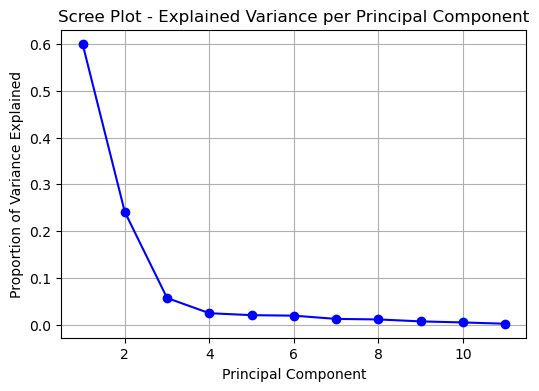

In [7]:
# 6️⃣ Scree Plot (individual explained variance)
plt.figure(figsize=(6,4))
plt.plot(range(1, len(explained_var)+1), explained_var, marker='o', color='b')
plt.title("Scree Plot - Explained Variance per Principal Component")
plt.xlabel("Principal Component")
plt.ylabel("Proportion of Variance Explained")
plt.grid(True)
plt.show()

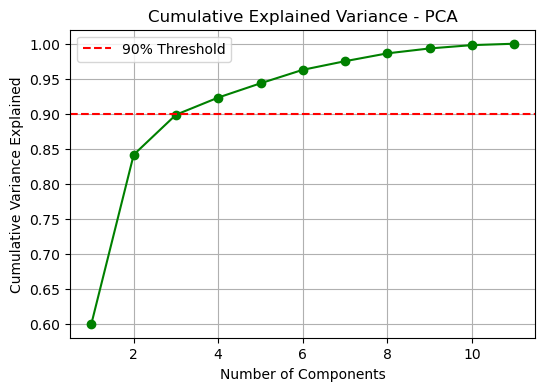

In [8]:
# 7️⃣ Cumulative Explained Variance Plot
plt.figure(figsize=(6,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o', color='green')
plt.axhline(y=0.9, color='red', linestyle='--', label='90% Threshold')
plt.title("Cumulative Explained Variance - PCA")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.legend()
plt.grid(True)
plt.show()

In [9]:
# 8️⃣ Determine number of components for ≥90% variance
min_comp = np.argmax(cum_var >= 0.90) + 1
print(f"\nMinimum number of components to retain ≥90% variance: {min_comp}")


Minimum number of components to retain ≥90% variance: 4


In [10]:
# 9️⃣ Display explained and cumulative variance table
variance_table = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(explained_var))],
    'Explained Variance (%)': np.round(explained_var * 100, 2),
    'Cumulative Variance (%)': np.round(cum_var * 100, 2)
})
print("\nExplained Variance Table:\n")
print(variance_table)


Explained Variance Table:

   Principal Component  Explained Variance (%)  Cumulative Variance (%)
0                  PC1                   60.08                    60.08
1                  PC2                   24.10                    84.17
2                  PC3                    5.70                    89.87
3                  PC4                    2.45                    92.32
4                  PC5                    2.03                    94.36
5                  PC6                    1.92                    96.28
6                  PC7                    1.23                    97.51
7                  PC8                    1.12                    98.63
8                  PC9                    0.70                    99.33
9                 PC10                    0.47                    99.80
10                PC11                    0.20                   100.00


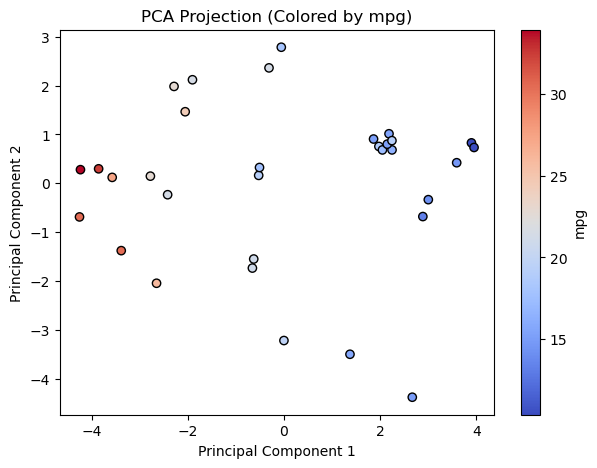

In [11]:
# 🔟 Visualize first two principal components (optional)
plt.figure(figsize=(7,5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=mtcars['mpg'], cmap='coolwarm', edgecolor='k')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection (Colored by mpg)')
plt.colorbar(label='mpg')
plt.show()